In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit_aer import AerSimulator
from shift_operators import ShiftDown, ShiftUp

In [2]:
n = 3
main = QuantumRegister(n, "j")
ancillae = QuantumRegister(2, "anc")

simulator = AerSimulator(method="unitary")

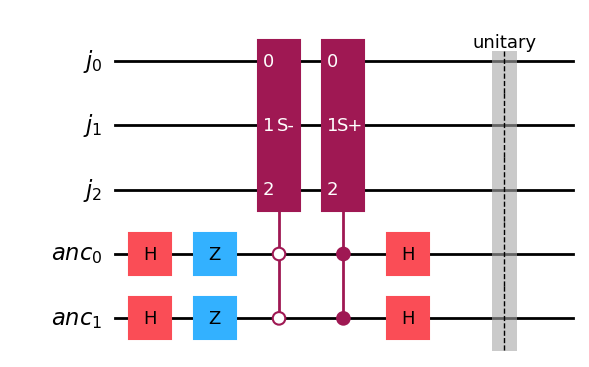

In [3]:
csdown = ShiftDown(n).control(2, ctrl_state=0)
csup = ShiftUp(n).control(2, ctrl_state=3)
qc = QuantumCircuit(main, ancillae)

# Block encoding
qc.h(ancillae)
qc.z(ancillae)
qc.append(csdown, ancillae[:] + main[:])
qc.append(csup, ancillae[:] + main[:])
qc.h(ancillae)
qc.save_unitary()

qc.draw(output="mpl")

In [4]:
qc = transpile(qc, simulator)

result = simulator.run(qc).result()
unitary = result.get_unitary(qc).data

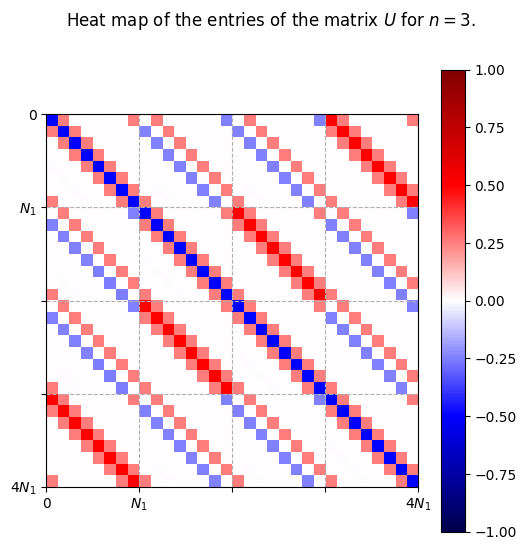

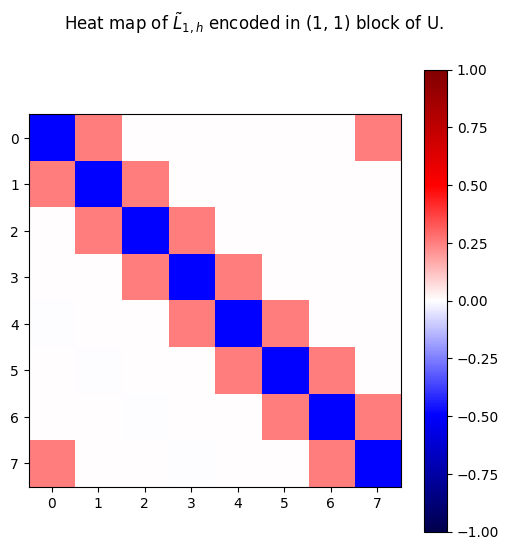

In [5]:
ticks = np.array(list(range(0, 2 ** 5 + 1, 8)))

plt.figure(figsize=(6, 6))
plt.suptitle("Heat map of the entries of the matrix $U$ for $n = 3$.")
plt.imshow(unitary.real, cmap="seismic", vmin=-1, vmax=1)
plt.colorbar()
plt.gca().set_xticks(ticks - 0.5)
plt.gca().set_xticklabels([0] + ["$N_1$"] + 2 * [None] + ["$4N_1$"])
plt.gca().set_yticks(ticks-0.5)
plt.gca().set_yticklabels([0] + ["$N_1$"] + 2 * [None] + ["$4N_1$"])
plt.grid(linestyle="--")
plt.show()

plt.figure(figsize=(6, 6))
plt.suptitle("Heat map of $\\tilde{L}_{{1, h}}$ encoded in (1, 1) block of U.")
plt.imshow(unitary[:8, :8].real, cmap="seismic", vmin=-1, vmax=1,)
plt.colorbar()
plt.show()

In [8]:
psi0 = [[1]]

for i in range(31):
    psi0.append([0])

psi0 = np.array(psi0)

(unitary @ psi0).real

array([[-5.00000000e-01],
       [ 2.50000000e-01],
       [ 0.00000000e+00],
       [ 2.03392218e-17],
       [-1.96540771e-16],
       [ 4.35390380e-17],
       [ 0.00000000e+00],
       [ 2.50000000e-01],
       [ 1.11022302e-16],
       [-2.50000000e-01],
       [ 0.00000000e+00],
       [ 2.03392218e-17],
       [ 2.42861287e-17],
       [-4.35390380e-17],
       [ 0.00000000e+00],
       [ 2.50000000e-01],
       [ 1.11022302e-16],
       [-2.50000000e-01],
       [ 0.00000000e+00],
       [ 2.03392218e-17],
       [-2.42861287e-17],
       [-4.35390380e-17],
       [ 0.00000000e+00],
       [ 2.50000000e-01],
       [ 5.00000000e-01],
       [ 2.50000000e-01],
       [ 0.00000000e+00],
       [ 2.03392218e-17],
       [ 1.96540771e-16],
       [ 4.35390380e-17],
       [ 0.00000000e+00],
       [ 2.50000000e-01]])